# Tumor evolution depending on the drug used

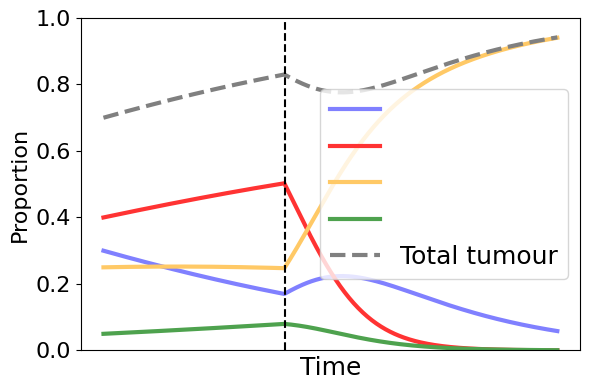

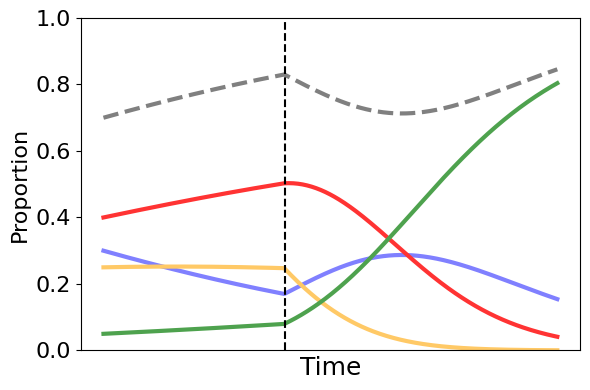

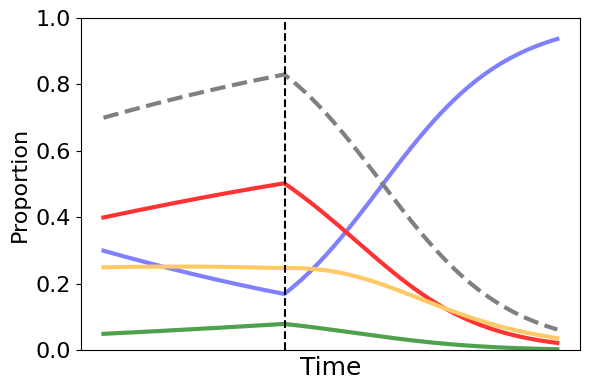

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Time grid
t = np.linspace(0, 20, 400)
t_break = 8
dt = t[1] - t[0]

# Initial proportions
init = {
    "blue": 0.3,
    "red": 0.4,
    "orange": 0.25,
    "green": 0.05
}

def simulate(rates_before, rates_after):
    blue = np.zeros_like(t)
    red = np.zeros_like(t)
    orange = np.zeros_like(t)
    green = np.zeros_like(t)

    blue[0] = init["blue"]
    red[0] = init["red"]
    orange[0] = init["orange"]
    green[0] = init["green"]

    for i in range(1, len(t)):
        r = rates_before if t[i] < t_break else rates_after

        blue[i] = blue[i-1] * np.exp(r["blue"] * dt)
        red[i] = red[i-1] * np.exp(r["red"] * dt)
        orange[i] = orange[i-1] * np.exp(r["orange"] * dt)
        green[i] = green[i-1] * np.exp(r["green"] * dt)

        total = blue[i] + red[i] + orange[i] + green[i]

        blue[i] /= total
        red[i] /= total
        orange[i] /= total
        green[i] /= total

    return blue, red, orange, green


# BEFORE breakpoint
rates_before = {
    "blue": -0.05,
    "red": 0.05,
    "orange": 0.02,
    "green": 0.08
}

scenarios = {
    "Scenario 1: Orange dominates": {
        "blue": -0.,
        "red": -0.5,
        "orange": 0.2,
        "green": -0.3
    },
    "Scenario 2: Green dominates": {
        "blue": -0.1,
        "red": -0.3,
        "orange": -0.6,
        "green": 0.1
    },
    "Scenario 3: Blue takes over": {
        "blue": 0.2,
        "red": -0.2,
        "orange": -0.1,
        "green": -0.2
    }
}

def xcolor_mix(rgb, percent):
    p = percent / 100
    return tuple(int(p*c + (1-p)*255) for c in rgb)

colors = {
    "orange": "#FFC966", # xcolor_mix((255,165,0), 60),
    "red": "#FF3333", # xcolor_mix((255,0,0), 80),
    "green": "#4EA24E", #xcolor_mix((34,139,34), 80),
    "blue": "#8080FF", # xcolor_mix((0,0,255), 20)
}

count = 0
for title, rates_after in scenarios.items():

    blue, red, orange, green = simulate(rates_before, rates_after)
    tumor = red + orange + green

    plt.figure(figsize=(6,4))

    plt.plot(t, blue, color=colors['blue'], linewidth=3,label=" ")
    plt.plot(t, red, color=colors["red"], linewidth=3,label=" ")
    plt.plot(t, orange, color=colors["orange"], linewidth=3,label=" ")
    plt.plot(t, green, color=colors["green"], linewidth=3, label=" ")
    plt.plot(t, tumor, color="gray", linewidth=3,linestyle = "--",  label="Total tumour")

    plt.axvline(t_break, linestyle="--", color="black")

    plt.xlabel("Time", fontsize=18)
    plt.xticks([])
    plt.yticks(fontsize=16)
    plt.ylabel("Proportion", fontsize=16)
    #plt.title(title)
    plt.ylim(0, 1)

    if count == 0:
        plt.legend(fontsize=18)
    count += 1
    plt.tight_layout()
    plt.savefig(f'evolution_{count}.png', dpi=250, bbox_inches='tight')
    plt.show()

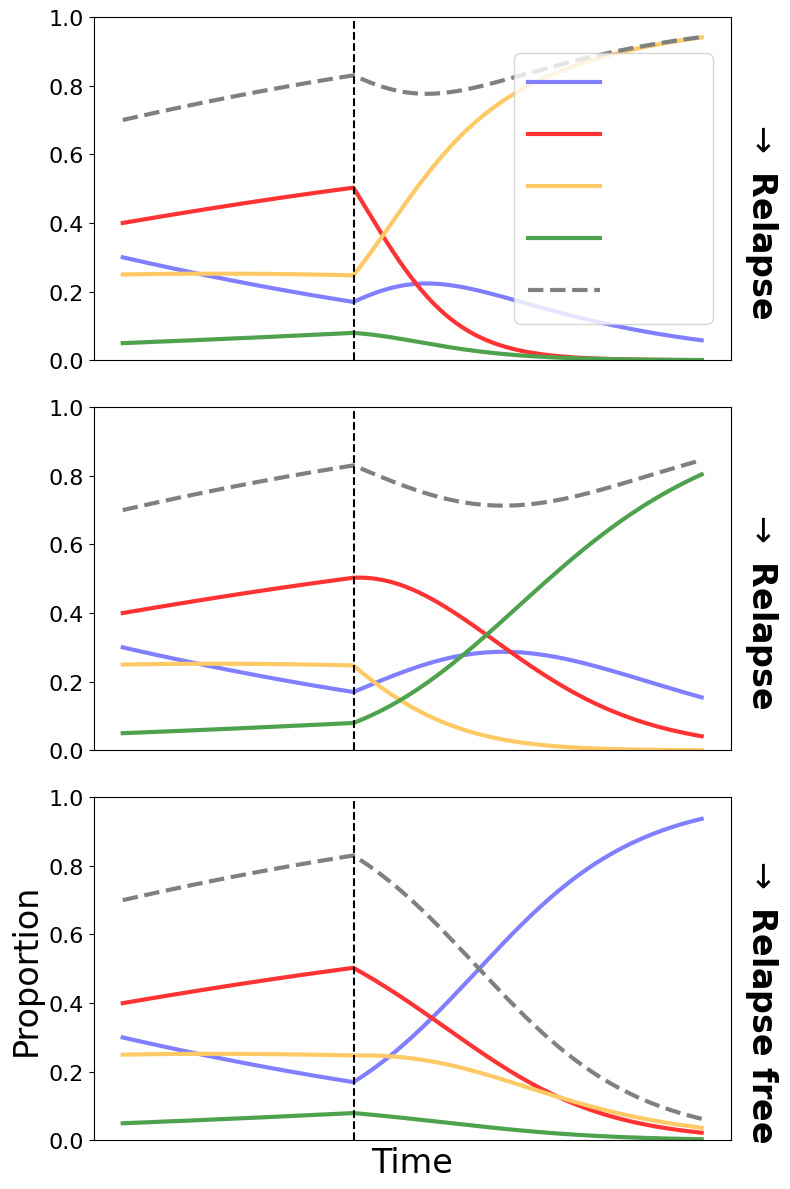

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Time grid
t = np.linspace(0, 20, 400)
t_break = 8
dt = t[1] - t[0]

# Initial proportions
init = {
    "blue": 0.3,
    "red": 0.4,
    "orange": 0.25,
    "green": 0.05
}

def simulate(rates_before, rates_after):
    blue = np.zeros_like(t)
    red = np.zeros_like(t)
    orange = np.zeros_like(t)
    green = np.zeros_like(t)

    blue[0] = init["blue"]
    red[0] = init["red"]
    orange[0] = init["orange"]
    green[0] = init["green"]

    for i in range(1, len(t)):
        r = rates_before if t[i] < t_break else rates_after

        blue[i] = blue[i-1] * np.exp(r["blue"] * dt)
        red[i] = red[i-1] * np.exp(r["red"] * dt)
        orange[i] = orange[i-1] * np.exp(r["orange"] * dt)
        green[i] = green[i-1] * np.exp(r["green"] * dt)

        total = blue[i] + red[i] + orange[i] + green[i]

        blue[i] /= total
        red[i] /= total
        orange[i] /= total
        green[i] /= total

    return blue, red, orange, green

# BEFORE breakpoint
rates_before = {
    "blue": -0.05,
    "red": 0.05,
    "orange": 0.02,
    "green": 0.08
}

scenarios = {
    "Scenario 1: Orange dominates": {
        "blue": -0.,
        "red": -0.5,
        "orange": 0.2,
        "green": -0.3
    },
    "Scenario 2: Green dominates": {
        "blue": -0.1,
        "red": -0.3,
        "orange": -0.6,
        "green": 0.1
    },
    "Scenario 3: Blue takes over": {
        "blue": 0.2,
        "red": -0.2,
        "orange": -0.1,
        "green": -0.2
    }
}

colors = {
    "orange": "#FFC966",
    "red": "#FF3333",
    "green": "#4EA24E",
    "blue": "#8080FF"
}

# Create vertical subplots
fig, axes = plt.subplots(3, 1, figsize=(8, 12), sharex=True)

texts = [r"     $\rightarrow$ Relapse", r"     $\rightarrow$ Relapse", r"     $\rightarrow$ Relapse free"]

for ax, (title, rates_after), text in zip(axes, scenarios.items(), texts):
    blue, red, orange, green = simulate(rates_before, rates_after)
    tumor = red + orange + green

    ax.plot(t, blue, color=colors['blue'], linewidth=3, label="      ")
    ax.plot(t, red, color=colors['red'], linewidth=3, label=" ")
    ax.plot(t, orange, color=colors['orange'], linewidth=3, label=" ")
    ax.plot(t, green, color=colors['green'], linewidth=3, label=" ")
    ax.plot(t, tumor, color="gray", linewidth=3, linestyle="--", label=" ")
    
    ax.axvline(t_break, linestyle="--", color="black")
    ax.set_ylim(0, 1)
    ax.set_xticks([])
    ax.tick_params(axis='y', labelsize=16)

    # Add text on the right
    ax.text(1.02, 0.5, text, transform=ax.transAxes, fontsize=24,
            rotation=-90, va="center", ha="left", fontweight="bold")

axes[-1].set_xlabel("Time", fontsize=24)
plt.subplots_adjust(wspace=0, hspace=0)

# Add legend to the first subplot
axes[0].legend(ncol=1, loc="center right", fontsize=26)
axes[2].set_ylabel("Proportion", fontsize=24)

plt.tight_layout()
plt.savefig(f'evolution.png', dpi=250, bbox_inches='tight')

plt.show()

# scRNA-seq

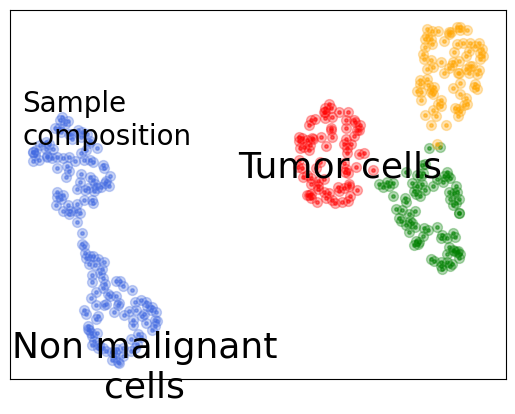

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc
import umap
from sklearn.datasets import make_blobs

# 1. Generate synthetic data for single-cell RNA-seq-like data (clusters)
n_samples = 400  # Number of cells
n_features = 2  # Number of genes (features)

centers = np.array([[0.5,0.5],[0.6, 0.5],[-1,-1], [-1,-1.1], [-1.1,-1]])

# Using sklearn's make_blobs to generate clustered data for illustration
X, y = make_blobs(n_samples=n_samples, centers=centers, cluster_std=0.02, n_features=n_features, random_state=22)

# 2. Create an AnnData object, which is the format used by Scanpy
adata = sc.AnnData(X)

# Assign the cluster labels
adata.obs['clusters'] = y

# 3. Rename clusters with specific names: Bcells, T cells, Tumor
cluster_names = ['B cells', 'T cells', 'Tumor', 'Tumor', 'Tumor']  # Example names for clusters
adata.obs['cluster_labels'] = [cluster_names[i] for i in y]

# 4. Perform UMAP on the synthetic data
sc.pp.neighbors(adata)  # Compute the neighborhood graph
sc.tl.umap(adata)       # Compute UMAP embedding

# 5. Customize UMAP Plot
plt.figure()

# Increase dot size and remove colorbar
# sc.pl.umap(adata, 
#            color='cluster_labels',  # Color by custom cluster labels
#            title='',
#            size=50,            # Increase dot size for better visibility
#            show=True,         # Don't automatically show the plot (we control it later)
#            color_map='tab10',  # Specify the color palette (you can change this)
#            legend_loc='best',  # Place legend on the data points
#            frameon=False)      # Remove frame around the plot

# Remove colorbar
#plt.gca().collections[0].set_edgecolor('none')  # Remove the edges of the dots for better clarity

# Optional: Customizing the colors for each cluster
custom_colors = ['royalblue', 'royalblue', 'green', 'orange', 'red']  # Custom colors for each cluster

# Manually apply colors to the clusters
for idx, cluster in enumerate(np.unique(y)):
    plt.scatter(adata.obsm['X_umap'][adata.obs['clusters'] == cluster, 0],
                adata.obsm['X_umap'][adata.obs['clusters'] == cluster, 1],
                c=custom_colors[idx],
                label=cluster_names[idx],  # Use the custom cluster names
                s=50, alpha=0.3)
    plt.scatter(adata.obsm['X_umap'][adata.obs['clusters'] == cluster, 0],
            adata.obsm['X_umap'][adata.obs['clusters'] == cluster, 1],
            c=custom_colors[idx],
             #label=cluster_names[idx],  # Use the custom cluster names
            s=6, alpha=0.5)

# Title and labels
#plt.title('UMAP Plot of Single-Cell Data', fontsize=16)

plt.xticks([])
plt.yticks([])

# Remove colorbar and legends manually
#plt.legend(loc='best', fontsize=24, labelspacing=0.1, borderpad=0.1, handletextpad=0.1)

if False:
    plt.text(-0.8, 4.5, 'B cells', horizontalalignment='left',
         verticalalignment='center', fontsize=26)
    plt.scatter(-1.1,4.5,c=custom_colors[0], s=64, alpha=0.9)

    plt.text(-0.8, 2.3, 'T cells', horizontalalignment='left',
         verticalalignment='center', fontsize=26)
    plt.scatter(-1.1,2.5,c=custom_colors[1], s=64, alpha=0.9)

    plt.text(-0.8, 0.1, 'Tumor cells', horizontalalignment='left',
         verticalalignment='center', fontsize=26)
    delta = 0.7
    plt.scatter(-1.1,0.1+delta,c=custom_colors[2], s=64, alpha=0.9)
    plt.scatter(-1.1,0.1,c=custom_colors[3], s=64, alpha=0.9)
    plt.scatter(-1.1,0.1-delta,c=custom_colors[4], s=64, alpha=0.9)
else:


    plt.text(-1.2, 0, 'Non malignant\ncells', horizontalalignment='center',
         verticalalignment='center', fontsize=26)

    plt.text(4, 8.1, 'Tumor cells', horizontalalignment='left',
         verticalalignment='center', fontsize=26)

plt.text(-8., 10, 'Sample\ncomposition', horizontalalignment='left',
     verticalalignment='center', fontsize=20)
#plt.savefig('umap.png', dpi=250, bbox_inches='tight')

plt.show()


# scDNA-seq

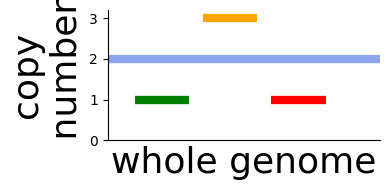

In [2]:
import matplotlib.pyplot as plt

# Define the segments for plotting
segments = [
    {"start": 0.1, "end": 0.3, "copy_number": 1, "color": "green"},
    {"start": 0.35, "end": 0.55, "copy_number": 3, "color": "orange"},
    {"start": 0.6, "end": 0.8, "copy_number": 1, "color": "red"}
]

# Create the plot
fig, ax = plt.subplots(figsize=(4,2))

# Add the horizontal reference line for copy number 2
ax.axhline(y=2, color='royalblue', linestyle='-', linewidth=6, alpha=0.6)

# Add the segments
for segment in segments:
    ax.hlines(
        y=segment["copy_number"],
        xmin=segment["start"],
        xmax=segment["end"],
        colors=segment["color"],
        linewidth=6
    )

# Customize the plot
ax.set_ylim(0, 3.2)
ax.set_xlim(0, 1)
plt.xticks([])
ax.set_ylabel("copy\n number", fontsize=26)
from matplotlib.ticker import MaxNLocator
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_xlabel("whole genome", fontsize=26)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Show the plot
plt.tight_layout()
#plt.savefig('dnaseq.png', dpi=250, bbox_inches='tight')

plt.show()


# Tumor evolution

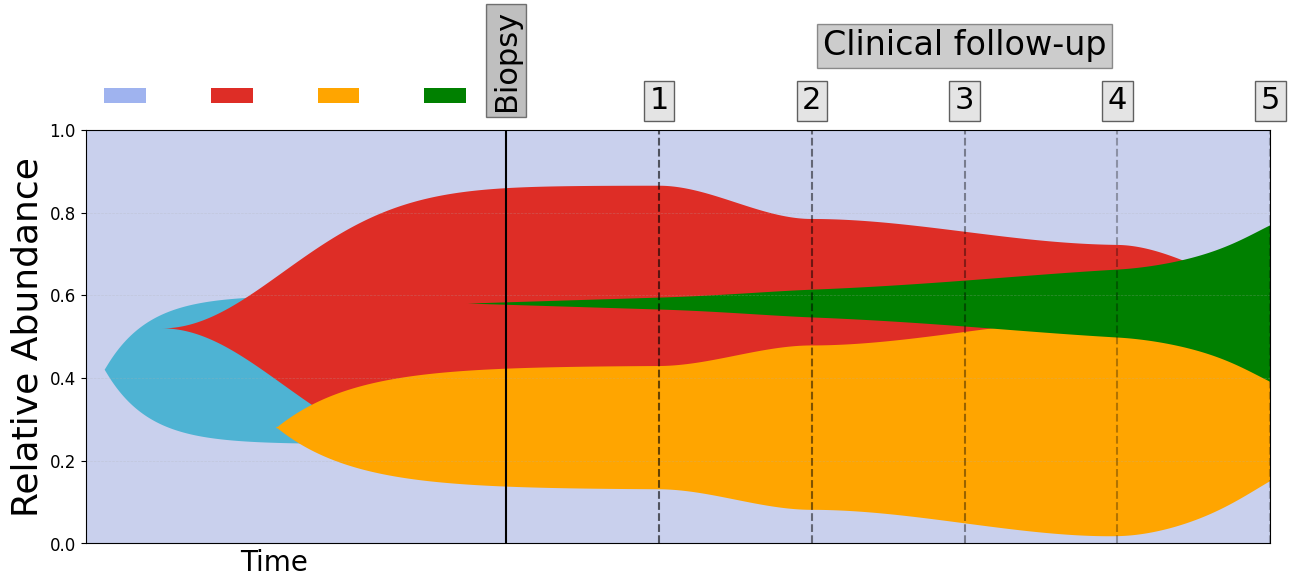

In [3]:
import numpy as np
import matplotlib.pyplot as plt


np.random.seed(5)
# =========================
# Time vector and follow-ups
# =========================
stepFU = 40
drug_effect_start0 = 110
drug_effect_start = drug_effect_start0 + 5 * stepFU

time = np.linspace(0, drug_effect_start, 500)

follow_up_times = [
    drug_effect_start0 + stepFU,
    drug_effect_start0 + 2 * stepFU,
    drug_effect_start0 + 3 * stepFU,
    drug_effect_start0 + 4 * stepFU,
    drug_effect_start0 + 5 * stepFU
]

fu_edges = np.concatenate(([drug_effect_start0], np.array(follow_up_times)[[0,1,3,4]]))
last_fu = follow_up_times[-1]

# =========================
# Initialize cell group abundances
# =========================
tumor_clone_1 = np.zeros_like(time)
tumor_clone_2 = np.zeros_like(time)
tumor_clone_1_child = np.zeros_like(time)
tumor_clone_2_child = np.zeros_like(time)

# =========================
# Tumor clone dynamics
# =========================
tumor_clone_1_growth = (1 - np.exp(-0.09 * (time - 5))) * (time >= 5)
tumor_clone_1 = tumor_clone_1_growth * 0.4
tumor_clone_1 *= (tumor_clone_1 > 0)

tumor_clone_1_child_growth = (
    1 - np.exp(-0.0005 * ((time - 20) * (time >= 20))**2)
) * (time >= 10)
tumor_clone_1_child = tumor_clone_1_child_growth * 0.6
tumor_clone_1_child *= (tumor_clone_1_child > 0)

tumor_clone_2_growth = (
    1 - np.exp(-0.05 * ((time - 50) * (time >= 50)))
) * (time >= 40)
tumor_clone_2 = tumor_clone_2_growth * 0.5
tumor_clone_2 *= (tumor_clone_2 > 0)

tumor_clone_2_child_growth = (
    1 - np.exp(-0.0002 * (time - 100))
) * (time >= 100)
tumor_clone_2_child = tumor_clone_2_child_growth * 1.7
tumor_clone_2_child *= (tumor_clone_2_child > 0)

#tumor_clone_1[time >= 50] = 0

# =========================
# Alternating smooth evolution between follow-ups
# =========================
def smooth_ramp(t, t0, t1, strength):
    """Smooth monotone multiplier from 1 to (1+strength)"""
    x = (t - t0) / (t1 - t0)
    x = np.clip(x, 0, 1)
    return 1 + strength * (3 * x**2 - 2 * x**3)  # smoothstep

for i in range(1,len(fu_edges) - 1):
    t0, t1 = fu_edges[i], fu_edges[i + 1]

    mask = (time >= t0) & (time < t1)
    mask2 = (time >= t1) 
    # Alternate direction every follow-up
    direction = -1 if np.random.rand() > 0.5 else 1

    # Mild effect for FU1–FU4
    if not (i in [0,2]):
        direction = -1 if np.random.rand() > 0.5 else 1
        strength_1_child = 0.14 * direction / tumor_clone_1_child[np.where(mask)[0][0]]
        direction = -1 if np.random.rand() > 0.5 else 1
        strength_2 = 0.18 * direction / tumor_clone_2[np.where(mask)[0][0]]
        direction = -1 if np.random.rand() > 0.5 else 1
        strength_2_child = 0.3
        if i==len(fu_edges):
            strength_1_child = - 0.3  /  tumor_clone_1_child[np.where(mask)[0][0]]
            strength_2 = - 0.3  / tumor_clone_2[np.where(mask)[0][0]]
            strength_2_child = 0.3 #/ tumor_clone_2_child[np.where(mask)[0][0]]


    tumor_clone_1_child[mask] *= smooth_ramp(time[mask], t0, t1, strength_1_child)
    tumor_clone_2[mask] *= smooth_ramp(time[mask], t0, t1, strength_2 * 0.9)
    tumor_clone_2_child[mask] *= smooth_ramp(time[mask], t0, t1, strength_2_child)
    
    tumor_clone_1_child[mask2] *= smooth_ramp(time[mask], t0, t1, strength_1_child)[-1]
    tumor_clone_2[mask2] *= smooth_ramp(time[mask], t0, t1, strength_2 * 0.9)[-1]
    tumor_clone_2_child[mask2] *= smooth_ramp(time[mask], t0, t1, strength_2_child)[-1]
    
    

# =========================
# Strong smooth final transition (last FU)
# =========================
def logistic(t, center, width):
    return 1 / (1 + np.exp(-(t - center) / width))

transition = logistic(time, last_fu, width=8)

tumor_clone_1_child *= (1 - 0.75 * transition)
tumor_clone_2 *= (1 - 0.80 * transition)
tumor_clone_2_child *= (1 + 0.90 * transition)

# =========================
# Width scaling (visual only)
# =========================
w_nm = 1.0
w_c1 = 0.9
w_c1_child = 1.15
w_c2 = 0.6
w_c2_child = 1.7

# =========================
# Plot layers
# =========================
plot_layers = [
    (0.5 - w_nm / 2, 0.5 + w_nm / 2, "royalblue", 0.18, ' '),
    (0.42 - w_c1 * tumor_clone_1 / 2, 0.42 + w_c1 * tumor_clone_1 / 2, "#4eb3d3", 1, None),
    (0.52 - w_c1_child * tumor_clone_1_child / 2, 0.52 + w_c1_child * tumor_clone_1_child / 2, "#de2d26", 1, ' '),
    (0.28 - w_c2 * tumor_clone_2 / 2, 0.28 + w_c2 * tumor_clone_2 / 2, "orange", 1, ' '),
    (0.58 - w_c2_child * tumor_clone_2_child / 2, 0.58 + w_c2_child * tumor_clone_2_child / 2, "green", 1, ' ')
]

# =========================
# Plot
# =========================
plt.figure(figsize=(13, 6))

for bottom, top, color, alpha, label in plot_layers:
    if label is None:
        plt.fill_between(time, bottom, top, color=color, alpha=alpha, edgecolor="none")
    elif color=="royalblue":
        plt.fill_between(time, bottom, top, color=color, edgecolor="none", alpha=alpha)
        plt.fill_between([], [],[], color=color, edgecolor="none", alpha=0.5, label=label)
    else:
        plt.fill_between(time, bottom, top, color=color, alpha=alpha, edgecolor="none", label=label)


xlabel = plt.xlabel("Time", loc="left", position=(40,0), fontsize=20)
xlabel.set_position((0.13, 0))  # x=0.5 center, y=-0.1 below the axis

plt.ylabel("Relative Abundance", fontsize=26)
plt.ylim(0, 1)
plt.xlim(0, time.max())
plt.xticks([])
plt.yticks(fontsize=12)

plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.3)
plt.gca().set_facecolor("midnightblue")
plt.gca().patch.set_alpha(0.1)

# =========================
# Clinical annotations
# =========================
plt.vlines(drug_effect_start0, 0, 1.04, color='black')
plt.text(drug_effect_start0, 1.06, 'Biopsy', rotation=90, fontsize=22,
         bbox=dict(facecolor='gray', alpha=0.5), ha='center')

alphas = [0.6, 0.5, 0.4, 0.3, 0.25]
for t, label, a in zip(follow_up_times, ['1', '2', '3', '4', '5'], alphas):
    plt.vlines(t, 0, 1, linestyle='--', color='black', alpha=a)
    plt.text(t, 1.05, label, fontsize=22, ha='center',
             bbox=dict(facecolor='lightgray', alpha=0.6))

plt.text(np.mean(follow_up_times), 1.18, 'Clinical follow-up',
         fontsize=24, ha='center',
         bbox=dict(facecolor='gray', alpha=0.4))

legend = plt.legend(
    loc='upper left',
    ncol=4,
    frameon=False,
    fontsize=15,
    bbox_to_anchor=(0., 1.15)
)

plt.tight_layout()
#plt.savefig("relative_abundance_with_drug_optimized.png", dpi=250, bbox_inches='tight')
plt.show()

# Effect of the different drugs: exponential decay

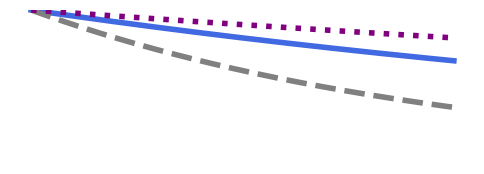

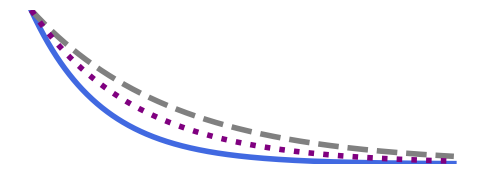

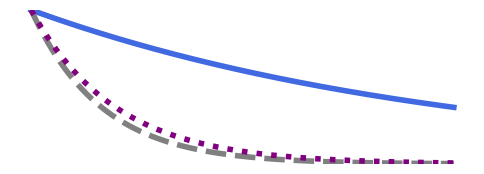

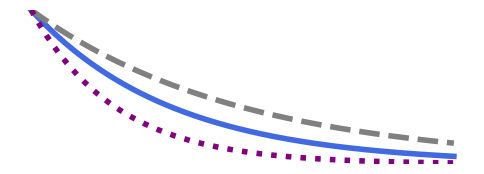

In [6]:
import matplotlib.pyplot as plt
import matplotlib.lines
from matplotlib.transforms import Bbox, TransformedBbox
from matplotlib.legend_handler import HandlerBase
from matplotlib.image import BboxImage
import numpy as np

class HandlerLineImage(HandlerBase):
    def __init__(self, path, space=15, offset=10, image_stretch=(1.0, 1.0)):
        """
        image_stretch: tuple(float, float)
            (horizontal_scale, vertical_scale) scaling factors for the image size
        """
        self.space = space
        self.offset = offset
        self.image_data = plt.imread(path)
        self.image_stretch = image_stretch
        super().__init__()

    def create_artists(self, legend, orig_handle,
                       xdescent, ydescent, width, height, fontsize, trans):

        # Draw line segment (color + style copied from original handle)
        line = matplotlib.lines.Line2D(
            [xdescent + self.offset, xdescent + (width - self.space) / 3. + self.offset],
            [ydescent + height / 2., ydescent + height / 2.])
        line.update_from(orig_handle)
        line.set_clip_on(False)
        line.set_transform(trans)

        # Calculate aspect ratio of the image
        aspect_ratio = self.image_data.shape[1] / self.image_data.shape[0]

        # Calculate the width and height of the image box with stretch factors
        img_width = height * aspect_ratio * self.image_stretch[0]
        img_height = height * self.image_stretch[1]

        # Compute bounding box for the image (right after line segment)
        bb = Bbox.from_bounds(
            xdescent + (width + self.space) / 3. + self.offset,
            ydescent,
            img_width,
            img_height)

        tbb = TransformedBbox(bb, trans)
        image = BboxImage(tbb)
        image.set_data(self.image_data)

        self.update_prop(image, orig_handle, legend)

        return [line, image]


def get_survival(i, name, rates=[0.3, 0.6, 1.0], loc='upper right', bbox=(1.14, 0.99)):
    # Create sample exponential decay curves
    t = np.linspace(0, 20, 500)
    colors = ['royalblue', 'gray', 'purple']
    ys = [np.exp(-r * t) for r in rates]

    fig, ax = plt.subplots(figsize=(6, 2))
    lines = []
    k=0
    styles=['-', '--', ':']
    for y, c in zip(ys, colors):
        line, = ax.plot(t, y, color=c, lw=4, linestyle=styles[k])
        lines.append(line)
        k+=1

    ax.set_xlabel('Time')
    string = f"{i}d"
    ax.set_ylabel(f"$\\pi_{{{string}}}$", fontsize=15)

    ax.grid(True, linestyle='--', alpha=0.9)

    ax.set_ylim(0,1)

    plt.xticks([])
    ax.set_axis_off()
    #plt.savefig(f'expo_{name}.png', dpi=300, bbox_inches='tight', transparent=True)
    plt.show()



ls = [['NM', [ 0.02 , 0.05, 0.01], "lower left", (-0.1,-0.1)],
     ['red', [ 0.6/2, 0.3/2, 0.4/2], 'upper right', None],
     ['orange', [0.1/2, 0.6/2, 0.5/2], 'upper right', None],
     ['green', [0.3/2, 0.2/2, 0.5/2], 'upper right', None]]

i=0
for name, rates, loc, bbox in ls:
    if bbox is None:
        get_survival(i, name, rates=rates, loc=loc)
    else:
        get_survival(i, name, rates=rates, loc=loc, bbox=bbox)
    i+=1